In [466]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Conv2D,MaxPool2D,Flatten

In [105]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

In [579]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

In [581]:
x_train.shape

(60000, 28, 28)

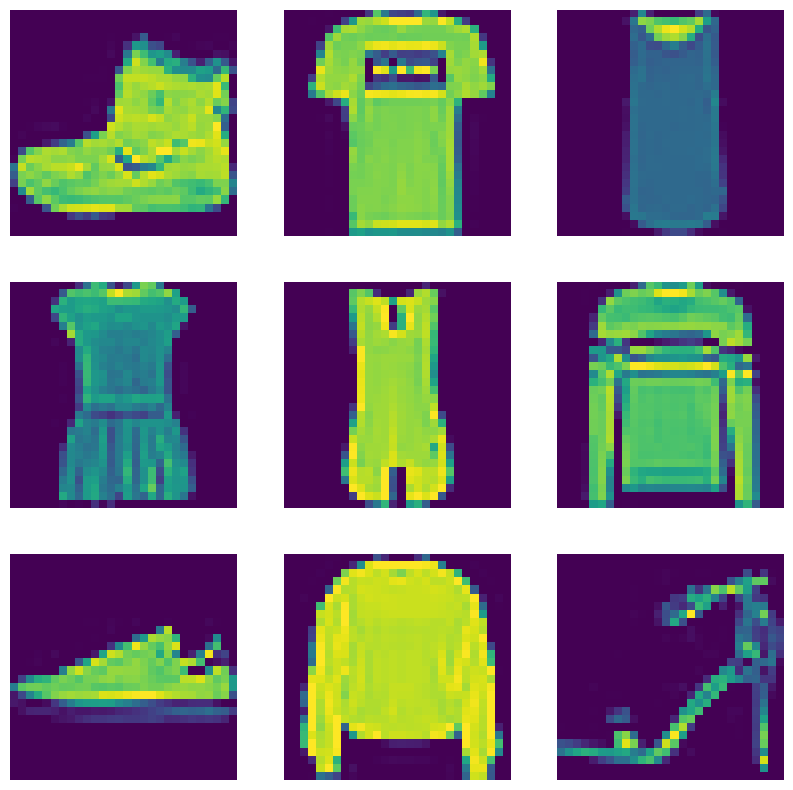

In [109]:
plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

In [583]:
X_train = x_train.reshape(-1, 28 * 28)
X_test = x_test.reshape(-1, 28 * 28)
X_train = X_train/225.
X_test = X_test/225.

In [587]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [589]:
y_train.shape

(60000, 10)

In [603]:
class Dense:
    def __init__(self, Input, Neurons, Lrate, total):
        self.Lrate = Lrate
        self.Total = total
        self.Bias = np.random.rand(Neurons)
        self.Weights = np.random.randn(Input, Neurons) * np.sqrt(1.0 / Input)
        # self.Weights = np.random.rand(Input, Neurons)
        self.Z = np.random.randn(Neurons)
    # Relu function
    def relu(self, Z):
        return np.maximum(0, Z)

    # Relu Derivative
    def relu_derivative(self, Z):
        return np.where(Z > 0, 1, 0)

    # Forward Propagation
    def Forward(self, X):
        self.Z = np.dot(X, self.Weights) + self.Bias  # Compute Z
        self.A = self.relu(self.Z)                 # Apply relu
        # print(self.Z)
        return self.A                                 # Return activations
    
    # Backward Propagation
    def Backward(self,X, dA, Weights):
        dZ = np.dot(dA, Weights.T) * self.relu_derivative(self.Z)
        # dZ = np.multiply(np.dot(dA,Weights.T),self.relu_derivative(self.Z))
        # relu_deriv = self.relu_derivative(self.Z)
        # if relu_deriv is None:
        #     raise ValueError("relu_derivative returned None. Check relu_derivative implementation.")
        # dZ = np.multiply(np.dot(dA, Weights.T), relu_deriv)
        grad_weights = np.dot(X.T, dZ) / self.Total  # Average over batch size
        grad_bias = np.sum(dZ, axis=0) / self.Total   # Average over batch size
        
        # Update weights and biases
        self.Weights += self.Lrate * grad_weights
        self.Bias += self.Lrate * grad_bias
        return dZ

In [605]:
class Output:
    def __init__(self, Input, Neurons, Lrate, total):
        self.Lrate = Lrate
        self.Total = total
        self.Bias = np.random.rand(Neurons)
        self.Weights = np.random.randn(Input, Neurons) * np.sqrt(1.0 / Input)
        # self.Weights = np.random.rand(Input, Neurons)
        
    # Softmax Function with numerical stability
    def softmax(self,z):
        assert len(z.shape) == 2
        s = np.max(z, axis=1)
        s = s[:, np.newaxis] # necessary step to do broadcasting
        e_x = np.exp(z - s)
        div = np.sum(e_x, axis=1)
        div = div[:, np.newaxis] # dito
        return e_x / div

    # Forward Propagation
    def Forward(self, X):
        self.Z = np.dot(X, self.Weights) + self.Bias  # Compute Z
        self.A = self.softmax(self.Z)                 # Apply softmax
        return self.A                                 # Return activations
    
    # Backward Propagation
    def Backward(self,X, dA):
        dZ = dA - self.A
        grad_weights = np.dot(X.T, dZ) / self.Total  # Average over batch size
        grad_bias = np.sum(dZ, axis=0) / self.Total   # Average over batch size
        
        # Update weights and biases
        self.Weights -= self.Lrate * grad_weights
        self.Bias += self.Lrate * grad_bias
        return dZ


In [629]:
epochs = 50
Layer1 = Dense(784,512,0.1,60000)
Layer2 = Dense(512,256,0.01,60000)
Layer3 = Dense(256,128,0.03,60000)
Out = Output(128,10,0.006,60000)
for _ in range(epochs):
    print(f"[________________________________________________________________________]EPOCHS::{_+1}")
    A1 = Layer1.Forward(X_train)
    A2 = Layer2.Forward(A1)
    A3 = Layer3.Forward(A2)
    O = Out.Forward(A3)
    
    Loss = Out.Backward(A3,y_train)
    W4 = Out.Weights
    Loss = Layer3.Backward(A2,Loss,W4)
    W3 = Layer3.Weights
    Loss = Layer2.Backward(A1,Loss,W3)
    W2 = Layer2.Weights
    Loss = Layer1.Backward(X_train,Loss,W2)

    A1 = Layer1.Forward(X_test)
    A2 = Layer2.Forward(A1)
    A3 = Layer3.Forward(A2)
    pred = Out.Forward(A3)
    # pred = model.Forward(X_test)
    print(calculate_accuracy(y_test,pred))

[________________________________________________________________________]EPOCHS::1
0.2271
[________________________________________________________________________]EPOCHS::2
0.3845
[________________________________________________________________________]EPOCHS::3
0.5291
[________________________________________________________________________]EPOCHS::4
0.5763
[________________________________________________________________________]EPOCHS::5
0.6108
[________________________________________________________________________]EPOCHS::6
0.6228
[________________________________________________________________________]EPOCHS::7
0.6374
[________________________________________________________________________]EPOCHS::8
0.6483
[________________________________________________________________________]EPOCHS::9
0.6581
[________________________________________________________________________]EPOCHS::10
0.6634
[________________________________________________________________________]EPOCHS::11
0.67

In [440]:
Loss

In [307]:
pred = model.Forward(X_test)

In [515]:
calculate_accuracy(y_test,pred)

0.1

In [321]:
def calculate_accuracy(y_true, y_pred):
    # Get the index of the maximum value (predicted class) for each prediction
    predicted_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_true,axis=1)
    # Compare the predicted class with the true class labels
    correct_predictions = np.sum(predicted_classes == y_true)
    accuracy = correct_predictions / len(y_true)
    return accuracy


In [263]:
def Accuracy(Actual, Predicted):
    # Actual = np.argmax(Actual)
    # Predicted = np.argmax(Predicted)
    Numbers = Actual[Actual == Predicted]
    return (Actual.shape[0]/Numbers.shape[0])

In [480]:
model = Sequential([
    Input(shape=(28*28,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics =['accuracy'])

In [482]:
model.fit(X_train, y_train, epochs=10,batch_size=128)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7703 - loss: 0.6531
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8660 - loss: 0.3663
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8825 - loss: 0.3218
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8902 - loss: 0.2931
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8974 - loss: 0.2744
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9031 - loss: 0.2606
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9032 - loss: 0.2508
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9106 - loss: 0.2371
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9116 - loss: 0.2300
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9185 - loss: 0.2141


In [484]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,304 (6.49 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,134,870 (4.33 MB)

In [125]:
Pred_test = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


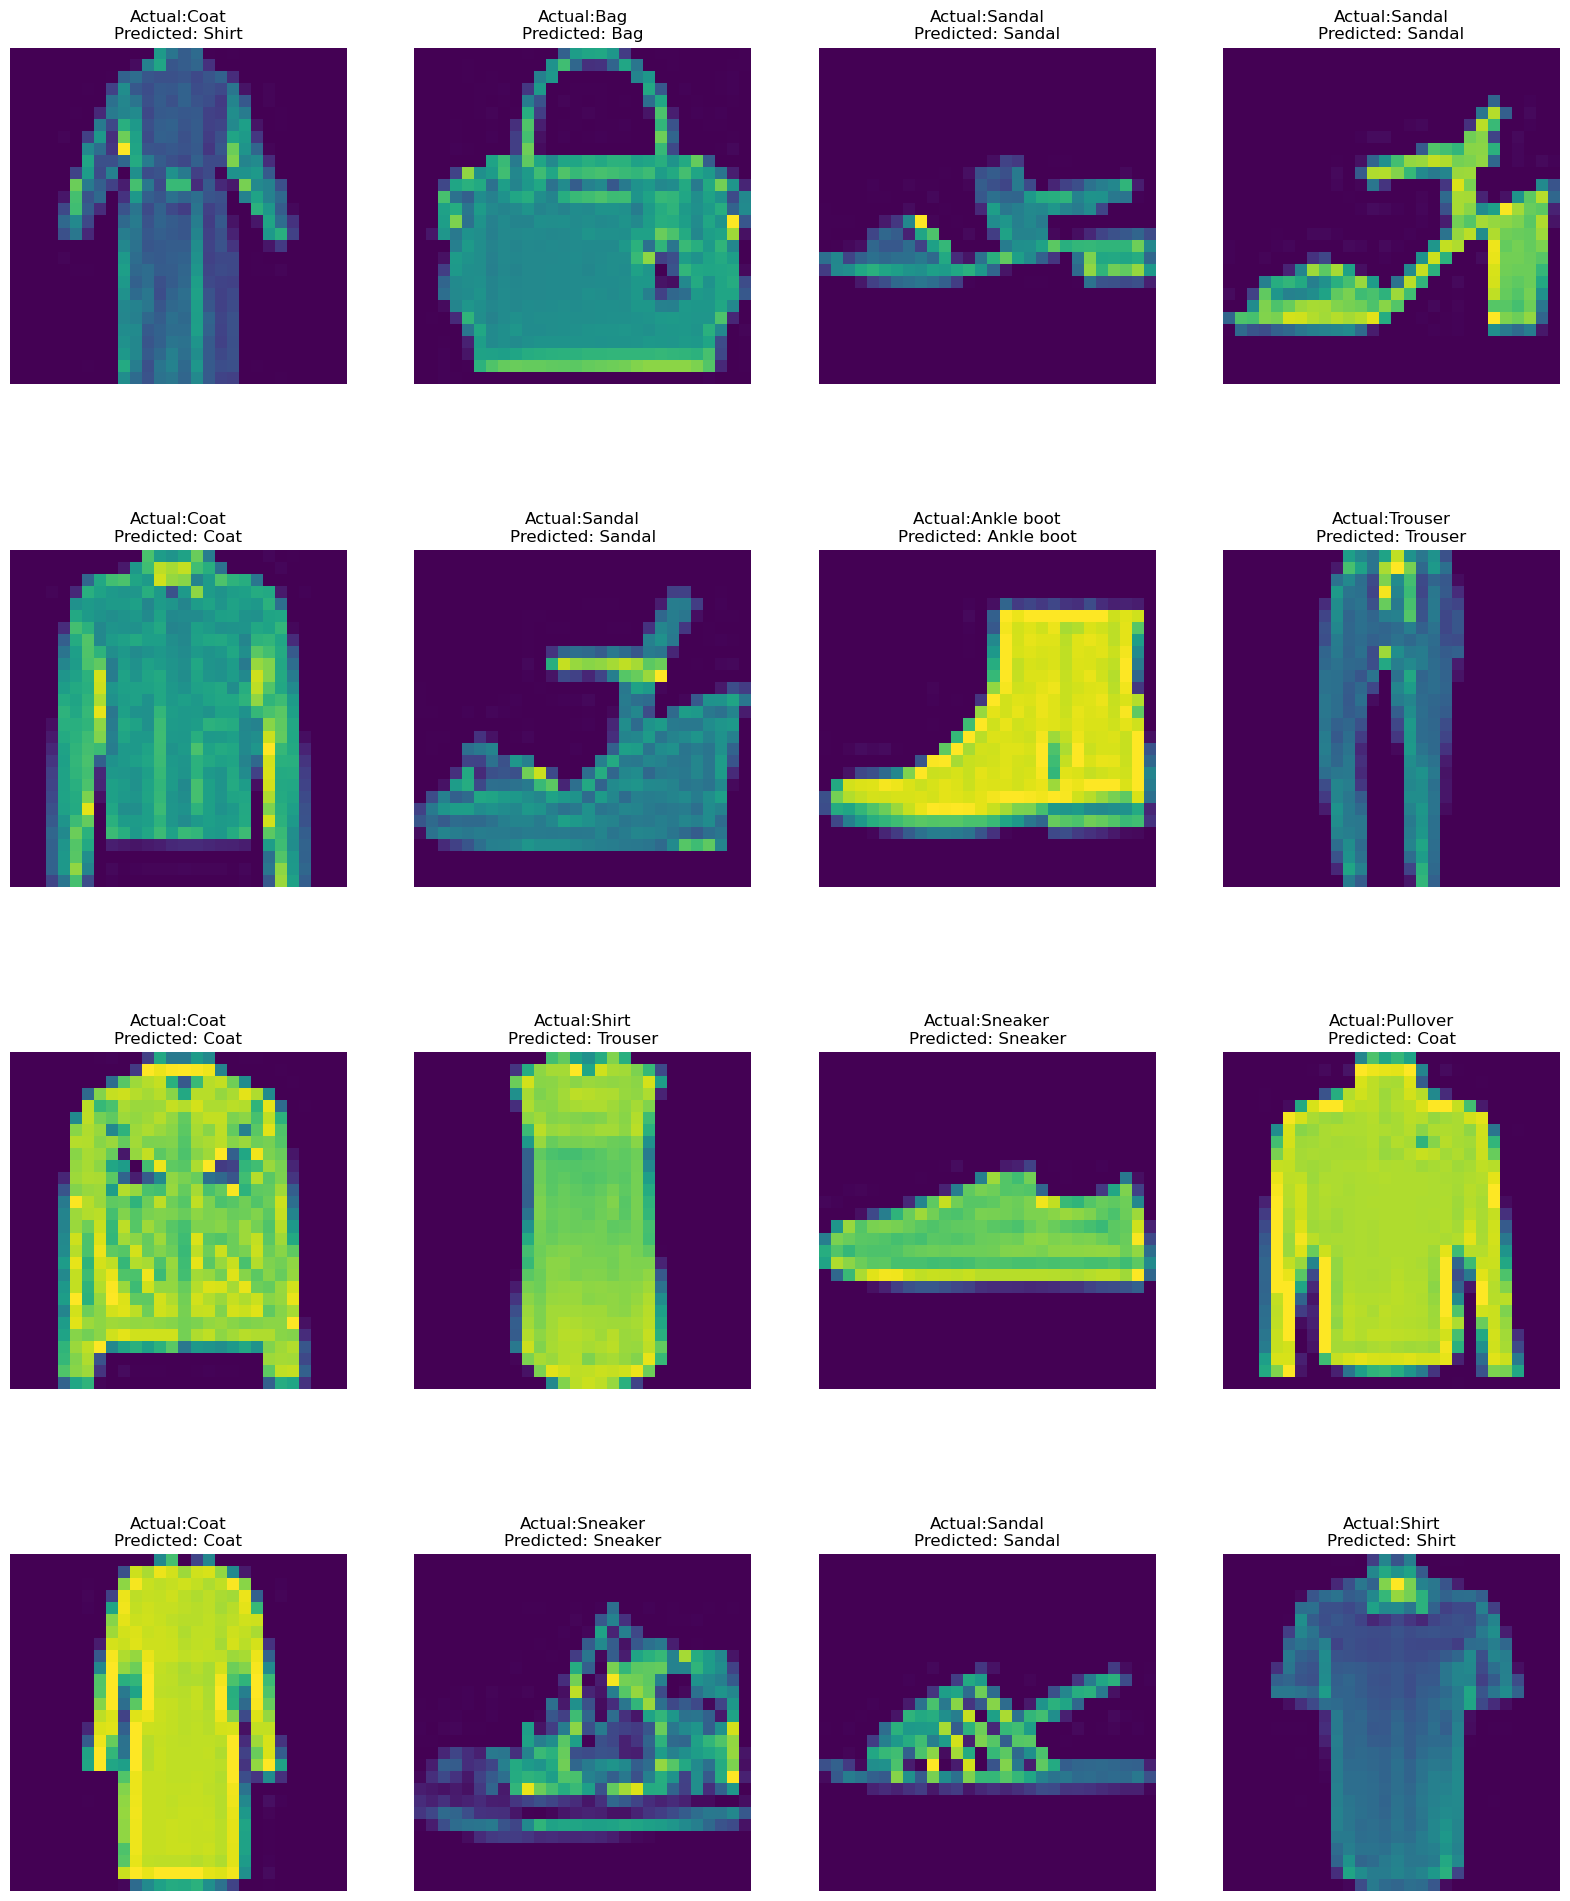

In [335]:
plt.figure(figsize=(20,25))
for i in range(16):
    ax = plt.subplot(4,4,i+1)
    j = random.randrange(6000)
    plt.title(f"Actual:{Classs[np.argmax(y_test[j])]}\nPredicted: {Classs[np.argmax(pred[j])]}")
    plt.imshow(x_test[j])
    plt.axis('off')
plt.show()

In [129]:
Classs = ['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']